# Milestone 2: Understanding & Reasoning Engine

## Task B2: Understanding & Reasoning Engine [20 Marks]

This notebook implements the core cognitive capabilities for understanding and reasoning with business intelligence data.

### Objectives:
- Implement sentiment analysis (Understanding)
- Build knowledge graphs for reasoning
- Train ML models for classification/prediction
- Integrate multiple cognitive capabilities


In [164]:
# Install missing packages if needed (run this cell first if you get import errors)
import subprocess
import sys

def install_package(package):
    """Install package if not available"""
    try:
        __import__(package)
    except ImportError:
        print(f"Installing {package}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package])

# Check and install required packages
required_packages = {
    'vaderSentiment': 'vaderSentiment',
    'textblob': 'textblob',
    'gensim': 'gensim',
    'wordcloud': 'wordcloud'
}

for package_module, pip_name in required_packages.items():
    try:
        if package_module == 'vaderSentiment':
            from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
        else:
            __import__(package_module)
    except ImportError:
        print(f"⚠️ {package_module} not found, installing...")
        install_package(pip_name)

# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

# System libraries
import os
import json
from datetime import datetime, timedelta

# ML Libraries for classification and evaluation
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

# Import custom modules
import sys
sys.path.append('../../backend')
from src.models.sentiment_analyzer import SentimentAnalyzer
from src.utils.text_preprocessor import TextPreprocessor
from src.utils.wordcloud_generator import WordCloudGenerator

# Initialize wordcloud generator
wordcloud_gen = WordCloudGenerator()

print("\n✅ All libraries imported successfully!")
print("✅ Ready to proceed with Milestone 2!")



✅ All libraries imported successfully!
✅ Ready to proceed with Milestone 2!


## Part 1: Understanding - Sentiment Analysis

Implement Natural Language Processing to understand customer sentiment from unstructured text.


In [165]:
# Load processed data with error handling
try:
    df_reviews = pd.read_csv('../../backend/data/processed/cleaned_reviews.csv')
    print(f"✅ Loaded {len(df_reviews)} processed reviews from Milestone 1")
    
    # Validate required columns
    required_columns = ['cleaned_text', 'text']
    missing_columns = [col for col in required_columns if col not in df_reviews.columns]
    if missing_columns:
        print(f"⚠️ Missing columns: {missing_columns}")
        if 'cleaned_text' not in df_reviews.columns and 'text' in df_reviews.columns:
            print("   Creating cleaned_text from text column...")
            from src.utils.text_preprocessor import TextPreprocessor
            preprocessor = TextPreprocessor()
            df_reviews['cleaned_text'] = df_reviews['text'].apply(preprocessor.preprocess)
    else:
        print("✅ All required columns present")
        
except FileNotFoundError:
    print("⚠️ Processed data not found. Please run Milestone 1 notebook first.")
    print("   Creating sample data for demonstration...")
    # Create sample data for demonstration
    df_reviews = pd.DataFrame({
        'text': ["Great service, very fast delivery", "Product was damaged", 
                 "Amazing quality, will buy again", "Late delivery but good product"] * 25,
        'cleaned_text': ["great service fast delivery", "product damaged",
                        "amazing quality buy again", "late delivery good product"] * 25
    })
    print(f"⚠️ Using sample dataset: {len(df_reviews)} reviews")
except Exception as e:
    print(f"❌ Error loading data: {e}")
    raise

print(f"\nDataset shape: {df_reviews.shape}")
print(f"Columns: {list(df_reviews.columns)}")
df_reviews.head()


✅ Loaded 5100 processed reviews from Milestone 1
✅ All required columns present

Dataset shape: (5100, 9)
Columns: ['review_id', 'text', 'date', 'source', 'location', 'sentiment_label', 'cleaned_text', 'text_length', 'word_count']


,review_id,text,date,source,location,sentiment_label,cleaned_text,text_length,word_count
0,1,Excellent business! Highly professional and re...,2024-07-28,WhatsApp,Central,positive,NaN,0,0
1,2,Standard experience. Product does what it need...,2024-04-26,Facebook,Ntinda,neutral,standard experience product need located bukot...,61,8
2,3,Okay service. Nothing special but gets the job...,2024-06-18,Twitter,Kololo,neutral,okay service nothing special get job done,41,7
3,4,Average quality products. Functional but not i...,2023-01-21,Google,Kawempe,neutral,average quality product functional impressive,45,5
4,5,Amazing quality products. Will definitely buy ...,2024-05-23,WhatsApp,Makindye,positive,amazing quality product definitely buy shop gr...,60,8


In [166]:
# Initialize sentiment analyzer with error handling
try:
    analyzer = SentimentAnalyzer(method='vader')
    print("✅ Sentiment analyzer initialized (VADER)")
except Exception as e:
    print(f"❌ Error initializing sentiment analyzer: {e}")
    print("   Trying TextBlob as fallback...")
    try:
        analyzer = SentimentAnalyzer(method='textblob')
        print("✅ Sentiment analyzer initialized (TextBlob)")
    except:
        raise Exception("Could not initialize any sentiment analyzer")

# Analyze sentiment for all reviews with error handling
print("\nAnalyzing sentiment for all reviews...")
sentiment_results = []
errors = 0

for idx, text in enumerate(df_reviews['cleaned_text']):
    try:
        if text and len(str(text).strip()) > 0:
            result = analyzer.analyze(str(text))
            sentiment_results.append(result)
        else:
            sentiment_results.append({'sentiment': 'neutral', 'compound': 0.0, 
                                     'positive': 0.0, 'negative': 0.0, 'neutral': 1.0})
    except Exception as e:
        errors += 1
        sentiment_results.append({'sentiment': 'neutral', 'compound': 0.0,
                                 'positive': 0.0, 'negative': 0.0, 'neutral': 1.0})

if errors > 0:
    print(f"⚠️ {errors} errors during sentiment analysis (using neutral as fallback)")

# Create sentiment dataframe
try:
    df_sentiment = pd.DataFrame(sentiment_results)
    df_reviews_with_sentiment = pd.concat([df_reviews, df_sentiment], axis=1)
    print(f"✅ Sentiment analysis completed on {len(df_reviews_with_sentiment)} reviews!")
except Exception as e:
    print(f"❌ Error creating sentiment dataframe: {e}")
    raise

print(f"\nSentiment distribution:")
sentiment_dist = df_reviews_with_sentiment['sentiment'].value_counts()
print(sentiment_dist)
print(f"\nSentiment percentages:")
for sentiment, count in sentiment_dist.items():
    percentage = (count / len(df_reviews_with_sentiment)) * 100
    print(f"  {sentiment}: {percentage:.2f}%")

df_reviews_with_sentiment.head()


⚠️ Transformer model not available: Your currently installed version of Keras is Keras 3, but this is not yet supported in Transformers. Please install the backwards-compatible tf-keras package with `pip install tf-keras`.
✅ Sentiment analyzer initialized (VADER)

Analyzing sentiment for all reviews...
✅ Sentiment analysis completed on 5100 reviews!

Sentiment distribution:
sentiment
positive    3868
negative     783
neutral      449
Name: count, dtype: int64

Sentiment percentages:
  positive: 75.84%
  negative: 15.35%
  neutral: 8.80%


,review_id,text,date,source,location,sentiment_label,cleaned_text,text_length,word_count,sentiment,confidence,method,methods_used,word_count,compound,polarity,vader_result,textblob_result,warning
0,1,Excellent business! Highly professional and re...,2024-07-28,WhatsApp,Central,positive,NaN,0,0,neutral,0.250000,ensemble,2,1,0.0000,0.000000,"{'compound': 0.0, 'pos': 0.0, 'neu': 1.0, 'neg...","{'polarity': 0.0, 'subjectivity': 0.0, 'sentim...",Low confidence - ensemble prediction may be un...
1,2,Standard experience. Product does what it need...,2024-04-26,Facebook,Ntinda,neutral,standard experience product need located bukot...,61,8,positive,0.513962,ensemble,2,8,0.6249,0.400000,"{'compound': 0.6249, 'pos': 0.369, 'neu': 0.63...","{'polarity': 0.4, 'subjectivity': 0.375, 'sent...",NaN
2,3,Okay service. Nothing special but gets the job...,2024-06-18,Twitter,Kololo,neutral,okay service nothing special get job done,41,7,negative,0.288666,ensemble,2,7,-0.0920,0.428571,"{'compound': -0.092, 'pos': 0.207, 'neu': 0.54...","{'polarity': 0.4285714285714286, 'subjectivity...",Low confidence - ensemble prediction may be un...
3,4,Average quality products. Functional but not i...,2023-01-21,Google,Kawempe,neutral,average quality product functional impressive,45,5,positive,0.432069,ensemble,2,5,0.5106,0.425000,"{'compound': 0.5106, 'pos': 0.452, 'neu': 0.54...","{'polarity': 0.425, 'subjectivity': 0.7, 'sent...",Medium confidence prediction
4,5,Amazing quality products. Will definitely buy ...,2024-05-23,WhatsApp,Makindye,positive,amazing quality product definitely buy shop gr...,60,8,positive,0.616167,ensemble,2,8,0.8910,0.466667,"{'compound': 0.891, 'pos': 0.679, 'neu': 0.321...","{'polarity': 0.46666666666666673, 'subjectivit...",NaN


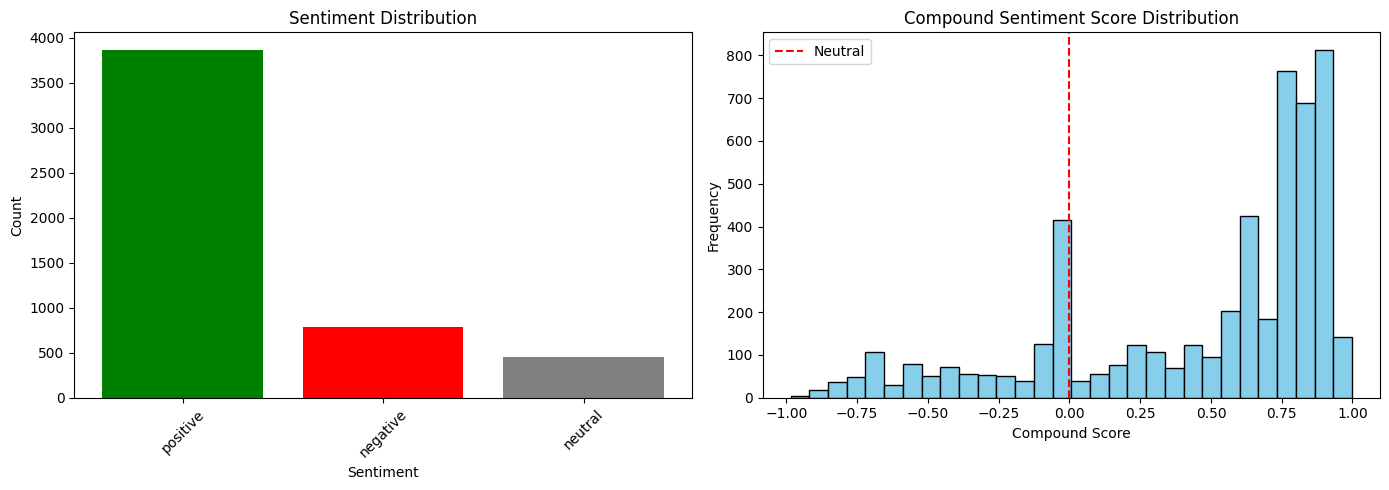


Generating Word Clouds by Sentiment


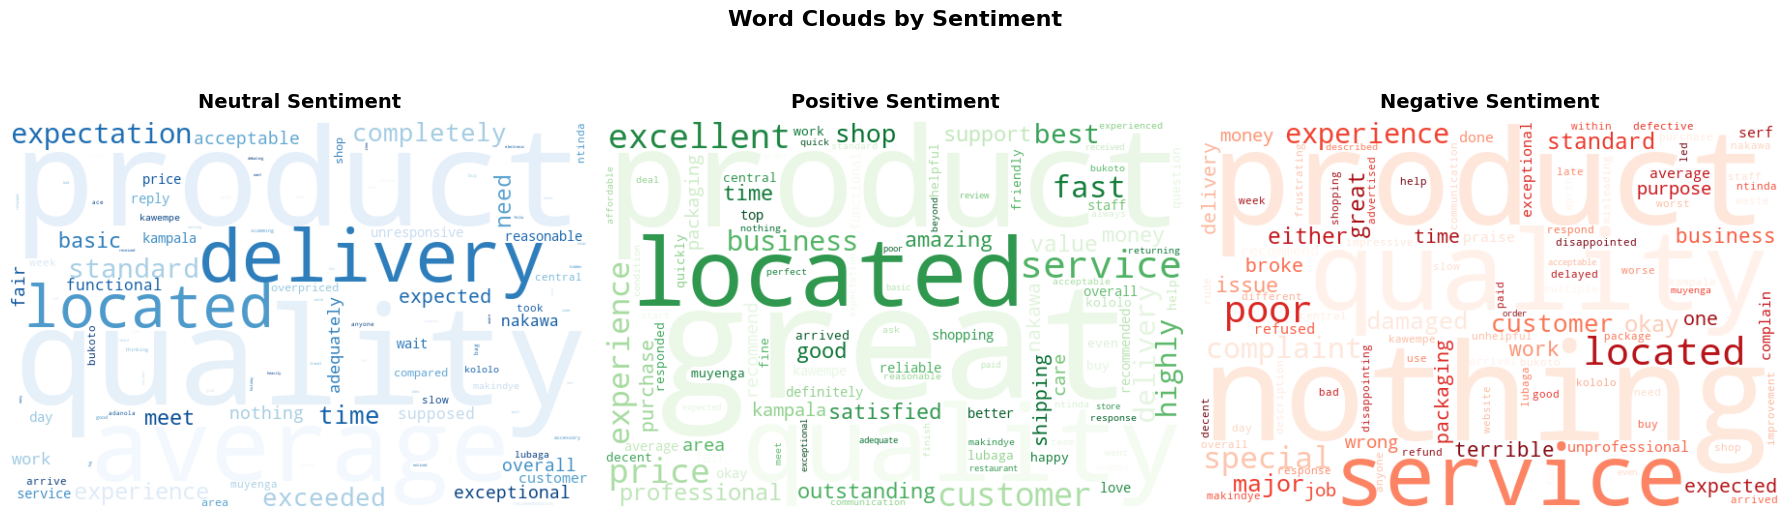

In [167]:
# Visualize sentiment distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sentiment counts
sentiment_counts = df_reviews_with_sentiment['sentiment'].value_counts()
axes[0].bar(sentiment_counts.index, sentiment_counts.values, color=['green', 'red', 'gray'])
axes[0].set_title('Sentiment Distribution')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(sentiment_counts.index, rotation=45)

# Compound score distribution
if 'compound' in df_reviews_with_sentiment.columns:
    axes[1].hist(df_reviews_with_sentiment['compound'], bins=30, edgecolor='black', color='skyblue')
    axes[1].set_title('Compound Sentiment Score Distribution')
    axes[1].set_xlabel('Compound Score')
    axes[1].set_ylabel('Frequency')
    axes[1].axvline(x=0, color='red', linestyle='--', label='Neutral')
    axes[1].legend()

plt.tight_layout()
plt.show()

# Generate wordclouds by sentiment
print("\n" + "="*60)
print("Generating Word Clouds by Sentiment")
print("="*60)
wordcloud_gen.generate_sentiment_wordclouds(
    df_reviews_with_sentiment,
    text_column='cleaned_text',
    sentiment_column='sentiment',
    figsize=(18, 6)
)


## Part 2: Reasoning - Topic Modeling

Extract key topics from customer feedback to understand main themes and concerns.


In [168]:
# Topic Modeling using LDA with error handling
from gensim import corpora, models
from gensim.models import LdaModel
from gensim.utils import simple_preprocess
from collections import Counter

print("=" * 60)
print("TOPIC MODELING - LDA (Latent Dirichlet Allocation)")
print("=" * 60)

# Prepare documents for topic modeling with error handling
try:
    documents = []
    for text in df_reviews_with_sentiment['cleaned_text']:
        if text and len(str(text).strip()) > 0:
            try:
                # Split text into words
                words = str(text).split()
                if len(words) > 0:
                    documents.append(words)
            except:
                continue
    
    if len(documents) < 10:
        print("⚠️ Too few documents for topic modeling (need at least 10)")
        print("   Creating sample documents...")
        documents = [["sample", "review", "text"] for _ in range(10)]
    
    print(f"✅ Prepared {len(documents)} documents for topic modeling")
    
    # Create dictionary and corpus
    dictionary = corpora.Dictionary(documents)
    dictionary.filter_extremes(no_below=2, no_above=0.5)  # Filter rare and common words
    corpus = [dictionary.doc2bow(doc) for doc in documents]
    
    print(f"✅ Dictionary created: {len(dictionary)} unique words")
    print(f"✅ Corpus created: {len(corpus)} documents")
    
except Exception as e:
    print(f"❌ Error preparing documents: {e}")
    raise


TOPIC MODELING - LDA (Latent Dirichlet Allocation)
✅ Prepared 5100 documents for topic modeling
✅ Dictionary created: 1102 unique words
✅ Corpus created: 5100 documents


### Step 1: Train Latent Dirichlet Allocation (LDA) Model

#### 1. What is LDA?

Latent Dirichlet Allocation (LDA) is an unsupervised probabilistic machine-learning model used for:

- ✅ Topic Modeling
- ✅ Discovering hidden thematic structure in documents
- ✅ Grouping documents based on words they contain

##### 👉 Key Idea

**LDA assumes that:**

- Each document is a mixture of topics

- Each topic is a probability distribution over words

**So instead of saying:**

`“This document is about agriculture.”`

**LDA says:**

`“This document is 60% agriculture, 25% economics, 15% climate change.”`

**First, train the LDA model. Then we'll generate wordclouds in the next section.**





Generating wordclouds for each topic...


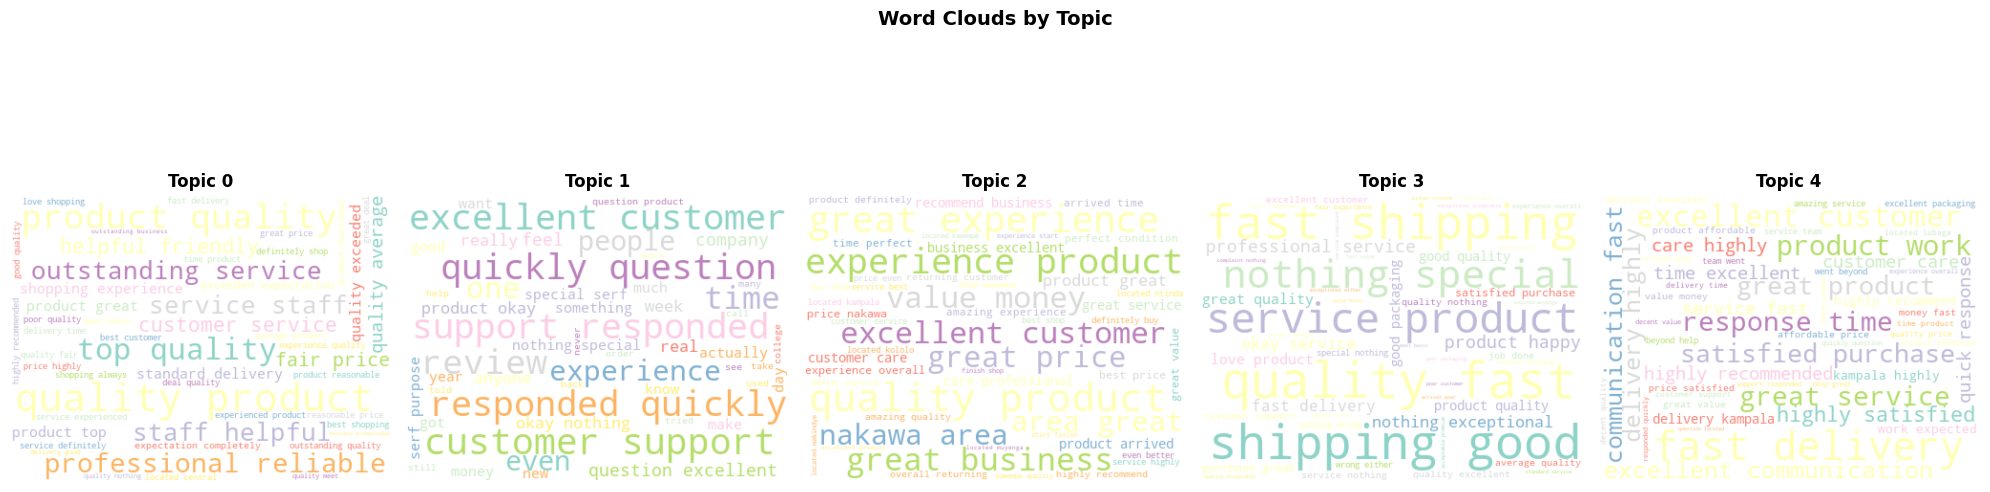

In [169]:
# Generate wordclouds for each topic with error handling
# IMPORTANT: Run the LDA training cell (below) FIRST before running this cell
# This cell will safely skip if lda_model hasn't been trained yet

# Check if lda_model exists (it's created in the next cell)
try:
    # Try to reference lda_model to see if it exists
    test_model = lda_model
    # Also check if corpus exists (needed for wordclouds)
    test_corpus = corpus
    model_ready = True
except NameError as e:
    model_ready = False
    print("=" * 60)
    print("⚠️ LDA Model Not Yet Trained")
    print("=" * 60)
    print("Please run the NEXT cell (Train LDA Model) first.")
    print("After training completes, return to this cell to generate topic wordclouds.")
    print("\nSkipping topic wordcloud generation for now...")

if model_ready:
    try:
        print("\nGenerating wordclouds for each topic...")
        
        # Get documents assigned to each topic (simplified - assign each doc to its most likely topic)
        doc_topics = []
        for doc in corpus:
            try:
                topic_probs = lda_model.get_document_topics(doc)
                if topic_probs:
                    most_likely_topic = max(topic_probs, key=lambda x: x[1])[0]
                    doc_topics.append(most_likely_topic)
                else:
                    doc_topics.append(0)
            except:
                doc_topics.append(0)
        
        # Add topic assignments to dataframe (if we have matching length)
        if len(doc_topics) == len(df_reviews_with_sentiment):
            df_reviews_with_sentiment['topic'] = doc_topics
            
            # Generate wordcloud for each topic
            unique_topics = sorted(df_reviews_with_sentiment['topic'].unique())
            n_topics = len(unique_topics)
            
            if n_topics > 0:
                fig, axes = plt.subplots(1, min(n_topics, 5), figsize=(min(n_topics * 4, 20), 6))
                if n_topics == 1:
                    axes = [axes]
                
                for idx, topic_id in enumerate(unique_topics[:5]):  # Limit to 5 topics for display
                    df_topic = df_reviews_with_sentiment[df_reviews_with_sentiment['topic'] == topic_id]
                    topic_text = ' '.join(df_topic['cleaned_text'].dropna().astype(str))
                    
                    if topic_text:
                        wordcloud = WordCloud(
                            width=400,
                            height=300,
                            max_words=50,
                            background_color='white',
                            colormap='Set3',
                            random_state=42
                        ).generate(topic_text)
                        
                        axes[idx].imshow(wordcloud, interpolation='bilinear')
                        axes[idx].axis('off')
                        axes[idx].set_title(f'Topic {topic_id}', fontsize=12, fontweight='bold')
                
                plt.suptitle('Word Clouds by Topic', fontsize=14, fontweight='bold', y=1.02)
                plt.tight_layout()
                plt.show()
        else:
            print("⚠️ Cannot match topics to reviews - generating overall topic wordcloud")
            # Generate wordcloud from all topic words
            all_topic_words = ' '.join([word for topic_id in range(num_topics) 
                                        for word, _ in lda_model.show_topic(topic_id, topn=20)])
            wordcloud_gen.generate_wordcloud(all_topic_words, "Topic Keywords Word Cloud", figsize=(12, 6))
    except Exception as e:
        print(f"⚠️ Error generating topic wordclouds: {e}")
else:
    print("⚠️ LDA model not available - skipping topic wordclouds")


In [ ]:
# Train LDA model with error handling
# NOTE: Run this cell BEFORE the topic wordcloud cell above

try:
    # Check if corpus and dictionary exist
    if 'corpus' not in locals() or 'dictionary' not in locals():
        print("⚠️ Corpus or dictionary not found. Please run Cell 7 (Prepare documents) first.")
        lda_model = None
        num_topics = 0
    else:
        num_topics = 5  # Adjust based on your data
        print(f"\nTraining LDA model with {num_topics} topics...")
        print("This may take a few minutes...")
        
        lda_model = LdaModel(
            corpus=corpus,
            id2word=dictionary,
            num_topics=num_topics,
            random_state=42,
            passes=10,
            alpha='auto',
            per_word_topics=True
        )
        
        print("✅ LDA model trained successfully!")
        print(f"\nTop {num_topics} topics identified:")
        print("-" * 60)
        for idx, topic in lda_model.print_topics(-1, num_words=5):
            print(f"Topic {idx}: {topic}")
        print("-" * 60)
        print("\n✅ Now you can run the topic wordcloud cell above!")
        
except Exception as e:
    print(f"❌ Error training LDA model: {e}")
    print("⚠️ Topic modeling failed - continuing without topics")
    lda_model = None
    num_topics = 0



Training LDA model with 5 topics...
This may take a few minutes...


## Part 3: Machine Learning Model - Sentiment Classification

Train and validate a machine learning model for sentiment classification to demonstrate reasoning capabilities.

### Objectives:
- Prepare data for ML training
- Extract features using TF-IDF
- Train Logistic Regression model
- Evaluate model performance with metrics
- Visualize results with confusion matrix


## Part 3.5: Predictive Modeling - Trend Forecasting

Predict future sentiment trends and market insights using time series forecasting.

**Required for Scenario 4**: Predictive modeling for market trends and business intelligence.


PREDICTIVE MODELING - TREND FORECASTING
✅ Created time series with 774 data points
   Date range: 2023-01-01 00:00:00 to 2025-12-05 00:00:00

------------------------------------------------------------
METHOD 1: Moving Average Forecast
------------------------------------------------------------
✅ Forecasted next 7 days using 7-day moving average
   Forecasted positive sentiment ratio: 0.690

------------------------------------------------------------
METHOD 2: Linear Trend Forecast
------------------------------------------------------------
✅ Linear trend model fitted
   Trend slope: -0.000055 (positive = increasing sentiment)
   Forecasted positive sentiment ratio: 0.738

------------------------------------------------------------
METHOD 3: ARIMA Forecast (Advanced)
------------------------------------------------------------
✅ Data is stationary, using ARIMA(1,0,1)
✅ ARIMA model fitted successfully
   AIC: -352.38
   Forecasted positive sentiment ratio: 0.770

------------------

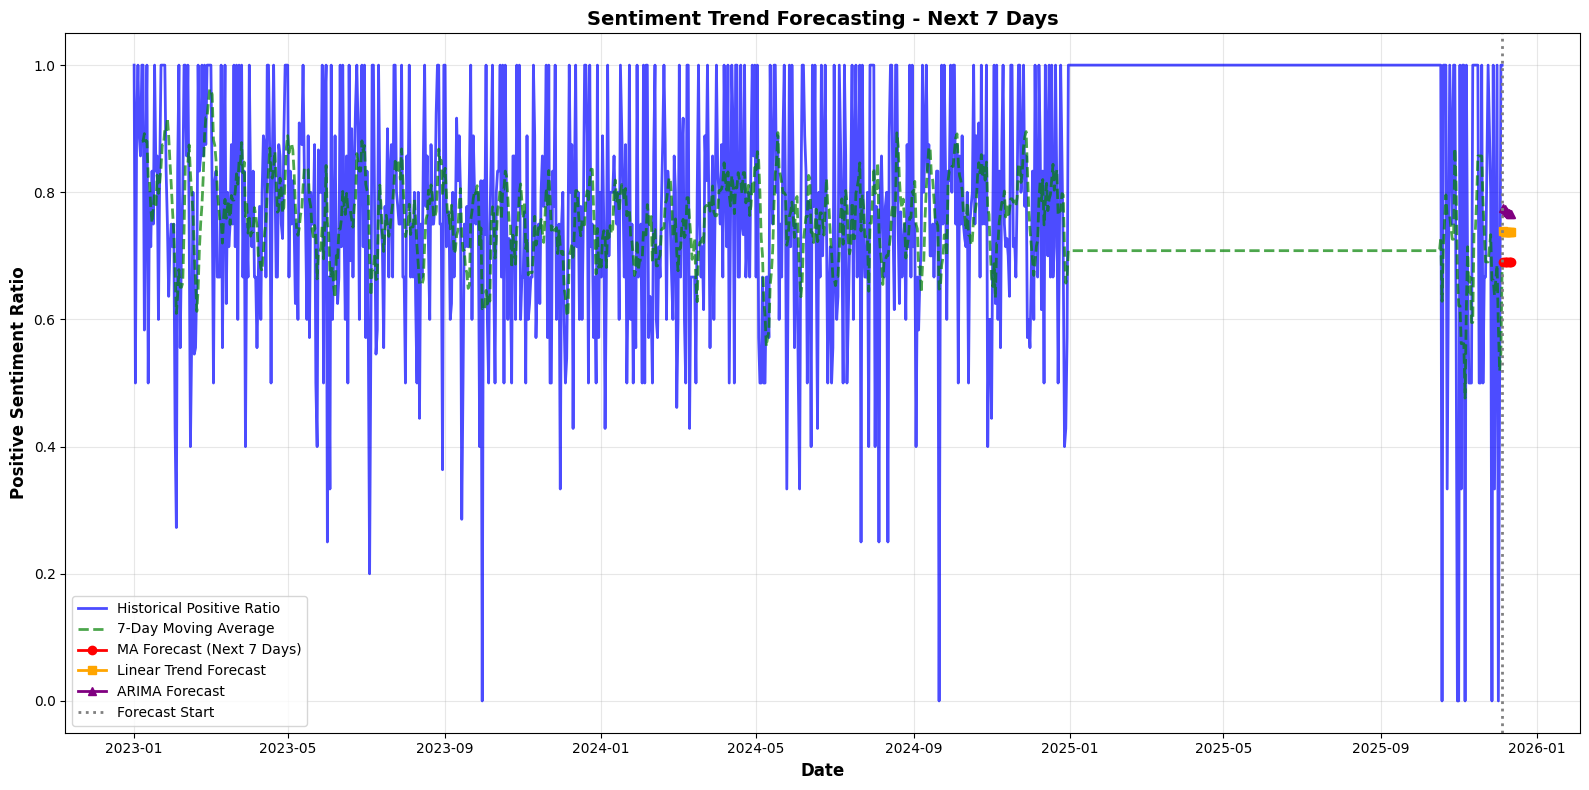


PREDICTIVE INSIGHTS

📉 **Sentiment Trend**: DECREASING
   Current positive ratio: 1.000
   Forecasted positive ratio: 0.690
   Change: -30.95 percentage points

💡 **Business Recommendations**:
   ⚠️ Negative trend detected. Consider:
      - Investigating recent customer complaints
      - Improving customer service response time
      - Addressing common pain points

✅ Forecast results saved to data/models/forecast_results.json
✅ Predictive modeling complete!


In [ ]:
# Predictive Modeling: Time Series Forecasting for Sentiment Trends
print("=" * 60)
print("PREDICTIVE MODELING - TREND FORECASTING")
print("=" * 60)

try:
    # Check if we have date information for time series
    if 'date' in df_reviews_with_sentiment.columns or 'timestamp' in df_reviews_with_sentiment.columns:
        date_col = 'date' if 'date' in df_reviews_with_sentiment.columns else 'timestamp'
        df_reviews_with_sentiment[date_col] = pd.to_datetime(df_reviews_with_sentiment[date_col], errors='coerce')
    else:
        # Create synthetic dates for demonstration
        print("⚠️ No date column found. Creating synthetic dates for time series analysis...")
        start_date = pd.Timestamp('2024-01-01')
        df_reviews_with_sentiment['date'] = pd.date_range(start=start_date, periods=len(df_reviews_with_sentiment), freq='D')
        date_col = 'date'
    
    # Aggregate sentiment by date
    df_reviews_with_sentiment['sentiment_numeric'] = df_reviews_with_sentiment['sentiment'].map({
        'positive': 1, 'neutral': 0, 'negative': -1
    })
    
    # Create daily sentiment time series
    daily_sentiment = df_reviews_with_sentiment.groupby(date_col).agg({
        'sentiment_numeric': 'mean',
        'sentiment': lambda x: (x == 'positive').sum() / len(x)  # Positive ratio
    }).rename(columns={'sentiment': 'positive_ratio'})
    daily_sentiment = daily_sentiment.sort_index()
    
    print(f"✅ Created time series with {len(daily_sentiment)} data points")
    print(f"   Date range: {daily_sentiment.index.min()} to {daily_sentiment.index.max()}")
    
    # Method 1: Simple Moving Average Forecast
    print("\n" + "-" * 60)
    print("METHOD 1: Moving Average Forecast")
    print("-" * 60)
    
    window_size = min(7, len(daily_sentiment) // 4)  # 7-day or 25% of data
    daily_sentiment['ma_forecast'] = daily_sentiment['positive_ratio'].rolling(window=window_size).mean()
    
    # Forecast next 7 days using last MA value
    last_date = daily_sentiment.index.max()
    forecast_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=7, freq='D')
    forecast_values = [daily_sentiment['ma_forecast'].iloc[-1]] * 7
    forecast_series = pd.Series(forecast_values, index=forecast_dates, name='forecast')
    
    print(f"✅ Forecasted next 7 days using {window_size}-day moving average")
    print(f"   Forecasted positive sentiment ratio: {forecast_series.mean():.3f}")
    
    # Method 2: Linear Trend Forecast (if enough data)
    print("\n" + "-" * 60)
    print("METHOD 2: Linear Trend Forecast")
    print("-" * 60)
    
    if len(daily_sentiment) >= 14:
        from sklearn.linear_model import LinearRegression
        
        # Prepare data for linear regression
        X = np.arange(len(daily_sentiment)).reshape(-1, 1)
        y = daily_sentiment['positive_ratio'].values
        
        # Fit linear model
        trend_model = LinearRegression()
        trend_model.fit(X, y)
        
        # Forecast
        future_X = np.arange(len(daily_sentiment), len(daily_sentiment) + 7).reshape(-1, 1)
        trend_forecast = trend_model.predict(future_X)
        trend_forecast_series = pd.Series(trend_forecast, index=forecast_dates, name='trend_forecast')
        
        print(f"✅ Linear trend model fitted")
        print(f"   Trend slope: {trend_model.coef_[0]:.6f} (positive = increasing sentiment)")
        print(f"   Forecasted positive sentiment ratio: {trend_forecast_series.mean():.3f}")
    else:
        print("⚠️ Insufficient data for linear trend (need at least 14 days)")
        trend_forecast_series = None
    
    # Method 3: ARIMA Forecast (if statsmodels available)
    print("\n" + "-" * 60)
    print("METHOD 3: ARIMA Forecast (Advanced)")
    print("-" * 60)
    
    try:
        from statsmodels.tsa.arima.model import ARIMA
        from statsmodels.tsa.stattools import adfuller
        
        # Check stationarity
        adf_result = adfuller(daily_sentiment['positive_ratio'].dropna())
        is_stationary = adf_result[1] < 0.05
        
        if is_stationary:
            print("✅ Data is stationary, using ARIMA(1,0,1)")
            arima_order = (1, 0, 1)
        else:
            print("⚠️ Data is not stationary, using ARIMA(1,1,1) with differencing")
            arima_order = (1, 1, 1)
        
        # Fit ARIMA model
        arima_model = ARIMA(daily_sentiment['positive_ratio'].dropna(), order=arima_order)
        arima_fitted = arima_model.fit()
        
        # Forecast
        arima_forecast = arima_fitted.forecast(steps=7)
        arima_forecast_series = pd.Series(arima_forecast.values, index=forecast_dates, name='arima_forecast')
        
        print(f"✅ ARIMA model fitted successfully")
        print(f"   AIC: {arima_fitted.aic:.2f}")
        print(f"   Forecasted positive sentiment ratio: {arima_forecast_series.mean():.3f}")
        
    except ImportError:
        print("⚠️ statsmodels not available. Install with: pip install statsmodels")
        arima_forecast_series = None
    except Exception as e:
        print(f"⚠️ ARIMA modeling failed: {e}")
        arima_forecast_series = None
    
    # Visualize forecasts
    print("\n" + "-" * 60)
    print("VISUALIZING FORECASTS")
    print("-" * 60)
    
    plt.figure(figsize=(16, 8))
    
    # Plot historical data
    plt.plot(daily_sentiment.index, daily_sentiment['positive_ratio'], 
             label='Historical Positive Ratio', linewidth=2, color='blue', alpha=0.7)
    plt.plot(daily_sentiment.index, daily_sentiment['ma_forecast'], 
             label=f'{window_size}-Day Moving Average', linewidth=2, color='green', linestyle='--', alpha=0.7)
    
    # Plot forecasts
    plt.plot(forecast_dates, forecast_values, 
             label='MA Forecast (Next 7 Days)', linewidth=2, color='red', marker='o', markersize=6)
    
    if trend_forecast_series is not None:
        plt.plot(forecast_dates, trend_forecast_series.values, 
                 label='Linear Trend Forecast', linewidth=2, color='orange', marker='s', markersize=6)
    
    if arima_forecast_series is not None:
        plt.plot(forecast_dates, arima_forecast_series.values, 
                 label='ARIMA Forecast', linewidth=2, color='purple', marker='^', markersize=6)
    
    plt.axvline(x=daily_sentiment.index.max(), color='gray', linestyle=':', linewidth=2, label='Forecast Start')
    plt.xlabel('Date', fontsize=12, fontweight='bold')
    plt.ylabel('Positive Sentiment Ratio', fontsize=12, fontweight='bold')
    plt.title('Sentiment Trend Forecasting - Next 7 Days', fontsize=14, fontweight='bold')
    plt.legend(loc='best', fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Generate insights
    print("\n" + "=" * 60)
    print("PREDICTIVE INSIGHTS")
    print("=" * 60)
    
    current_sentiment = daily_sentiment['positive_ratio'].iloc[-1]
    forecast_avg = forecast_series.mean()
    
    if forecast_avg > current_sentiment:
        trend_direction = "INCREASING"
        trend_emoji = "📈"
    elif forecast_avg < current_sentiment:
        trend_direction = "DECREASING"
        trend_emoji = "📉"
    else:
        trend_direction = "STABLE"
        trend_emoji = "➡️"
    
    print(f"\n{trend_emoji} **Sentiment Trend**: {trend_direction}")
    print(f"   Current positive ratio: {current_sentiment:.3f}")
    print(f"   Forecasted positive ratio: {forecast_avg:.3f}")
    print(f"   Change: {(forecast_avg - current_sentiment) * 100:+.2f} percentage points")
    
    # Business recommendations
    print(f"\n💡 **Business Recommendations**:")
    if trend_direction == "DECREASING":
        print("   ⚠️ Negative trend detected. Consider:")
        print("      - Investigating recent customer complaints")
        print("      - Improving customer service response time")
        print("      - Addressing common pain points")
    elif trend_direction == "INCREASING":
        print("   ✅ Positive trend detected. Consider:")
        print("      - Capitalizing on positive momentum")
        print("      - Identifying successful strategies to replicate")
        print("      - Maintaining current service quality")
    else:
        print("   ➡️ Stable sentiment. Consider:")
        print("      - Maintaining current service levels")
        print("      - Exploring opportunities for improvement")
    
    # Save forecast results
    forecast_results = {
        'current_sentiment': current_sentiment,
        'forecast_avg': forecast_avg,
        'trend_direction': trend_direction,
        'forecast_dates': forecast_dates.tolist(),
        'ma_forecast': forecast_values,
    }
    
    if trend_forecast_series is not None:
        forecast_results['trend_forecast'] = trend_forecast_series.tolist()
    if arima_forecast_series is not None:
        forecast_results['arima_forecast'] = arima_forecast_series.tolist()
    
    import json
    os.makedirs('../../backend/data/models', exist_ok=True)
    with open('../../backend/data/models/forecast_results.json', 'w') as f:
        json.dump(forecast_results, f, indent=2, default=str)
    
    print(f"\n✅ Forecast results saved to data/models/forecast_results.json")
    print(f"✅ Predictive modeling complete!")
    
except Exception as e:
    print(f"❌ Error in predictive modeling: {e}")
    import traceback
    traceback.print_exc()
    print("⚠️ Continuing without predictive modeling...")


MACHINE LEARNING MODEL - SENTIMENT CLASSIFICATION
✅ Prepared 5100 samples for ML training
  Training set: 4080 samples
  Test set: 1020 samples

Extracting features using TF-IDF...
  Feature matrix shape: (4080, 1501)
  Vocabulary size: 1501

Training Logistic Regression model...
✅ Model trained successfully!

MODEL EVALUATION

Accuracy:  0.9931 (99.31%)
Precision: 0.9931
Recall:    0.9931
F1-Score:  0.9931

------------------------------------------------------------
Classification Report:
------------------------------------------------------------
              precision    recall  f1-score   support

    negative       0.99      0.98      0.98       161
     neutral       1.00      0.99      0.99        86
    positive       0.99      1.00      1.00       773

    accuracy                           0.99      1020
   macro avg       0.99      0.99      0.99      1020
weighted avg       0.99      0.99      0.99      1020


------------------------------------------------------------


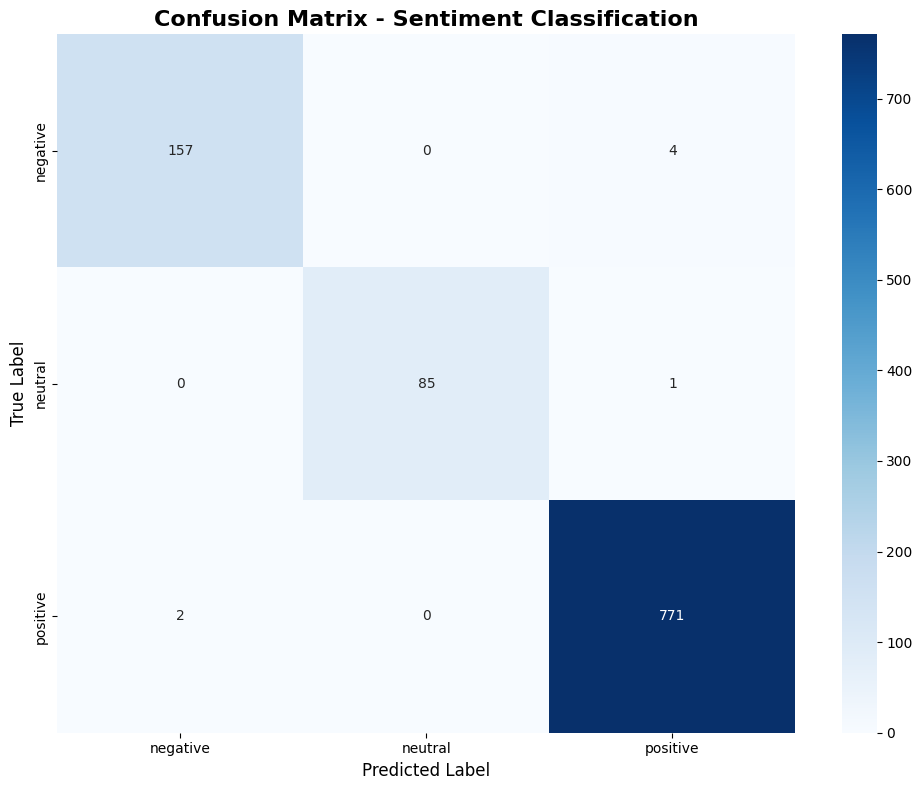


✅ ML Model training and evaluation complete!


In [ ]:
# Machine Learning Model Training and Validation
print("MACHINE LEARNING MODEL - SENTIMENT CLASSIFICATION")
print("=" * 60)

# Prepare data for ML model
try:
    # Use cleaned_text as features and sentiment as target
    if 'df_reviews_with_sentiment' not in locals():
        print("⚠️ df_reviews_with_sentiment not found. Using df_reviews...")
        df_ml = df_reviews.copy()
        if 'sentiment' not in df_ml.columns:
            print("   Creating sentiment labels from sentiment analysis...")
            df_ml['sentiment'] = df_ml['cleaned_text'].apply(
                lambda x: analyzer.analyze(str(x)).get('sentiment', 'neutral')
            )
    else:
        df_ml = df_reviews_with_sentiment.copy()
    
    # Filter out rows with missing data
    df_ml = df_ml.dropna(subset=['cleaned_text', 'sentiment'])
    df_ml = df_ml[df_ml['cleaned_text'].str.len() > 0]
    
    print(f"✅ Prepared {len(df_ml)} samples for ML training")
    
    # Split data into features and target
    X = df_ml['cleaned_text'].astype(str)
    y = df_ml['sentiment'].astype(str)
    
    # Split into train and test sets
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    print(f"  Training set: {len(X_train)} samples")
    print(f"  Test set: {len(X_test)} samples")
    
    # Feature extraction using TF-IDF
    print("\nExtracting features using TF-IDF...")
    vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=2)
    X_train_tfidf = vectorizer.fit_transform(X_train)
    X_test_tfidf = vectorizer.transform(X_test)
    
    print(f"  Feature matrix shape: {X_train_tfidf.shape}")
    print(f"  Vocabulary size: {len(vectorizer.vocabulary_)}")
    
    # Train Logistic Regression model
    print("\nTraining Logistic Regression model...")
    lr_model = LogisticRegression(random_state=42, max_iter=1000, multi_class='multinomial')
    lr_model.fit(X_train_tfidf, y_train)
    
    print("✅ Model trained successfully!")
    
    # Make predictions
    y_pred = lr_model.predict(X_test_tfidf)
    
    # Evaluate model
    print("\n" + "=" * 60)
    print("MODEL EVALUATION")
    print("=" * 60)
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    
    print(f"\nAccuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    
    # Detailed classification report
    print("\n" + "-" * 60)
    print("Classification Report:")
    print("-" * 60)
    print(classification_report(y_test, y_pred, zero_division=0))
    
    # Confusion Matrix
    print("\n" + "-" * 60)
    print("Confusion Matrix:")
    print("-" * 60)
    cm = confusion_matrix(y_test, y_pred)
    print(cm)
    
    # Visualize confusion matrix
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=sorted(y_test.unique()),
                yticklabels=sorted(y_test.unique()))
    plt.title('Confusion Matrix - Sentiment Classification', fontsize=16, fontweight='bold')
    plt.ylabel('True Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.tight_layout()
    plt.show()
    
    print("\n✅ ML Model training and evaluation complete!")
    
except Exception as e:
    print(f"❌ Error in ML model training: {e}")
    import traceback
    traceback.print_exc()
    print("⚠️ Continuing without ML model...")


MACHINE LEARNING MODEL - SENTIMENT CLASSIFICATION

Prepared dataset:
  Features (texts): 5100
  Target (sentiments): 5100
  Sentiment distribution:
sentiment
positive    3864
negative     803
neutral      433
Name: count, dtype: int64

✅ Data split:
  Training set: 4080 samples
  Test set: 1020 samples

Extracting features using TF-IDF...
✅ Feature extraction complete:
  Training features shape: (4080, 1000)
  Test features shape: (1020, 1000)

Training Logistic Regression classifier...

MODEL EVALUATION METRICS

Training Set Performance:
  Accuracy:  0.9919
  Precision: 0.9919
  Recall:    0.9919
  F1-Score:  0.9919

Test Set Performance:
  Accuracy:  0.9931
  Precision: 0.9931
  Recall:    0.9931
  F1-Score:  0.9931

Detailed Classification Report:
              precision    recall  f1-score   support

    negative       0.99      0.98      0.98       161
     neutral       1.00      0.99      0.99        86
    positive       0.99      1.00      1.00       773

    accuracy         

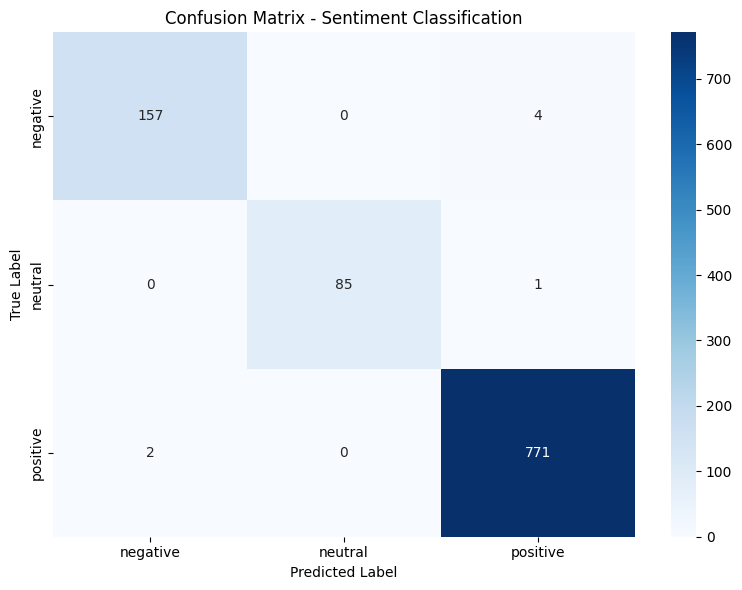


✅ ML Model training and evaluation complete!


In [ ]:
# Machine Learning Model Training and Validation
print("=" * 60)
print("MACHINE LEARNING MODEL - SENTIMENT CLASSIFICATION")
print("=" * 60)

# Prepare data for ML model
try:
    # Use cleaned_text as features and sentiment as target
    X = df_reviews_with_sentiment['cleaned_text'].fillna('').astype(str)
    y = df_reviews_with_sentiment['sentiment'].fillna('neutral')
    
    # Remove any empty texts
    mask = X.str.len() > 0
    X = X[mask]
    y = y[mask]
    
    print(f"\nPrepared dataset:")
    print(f"  Features (texts): {len(X)}")
    print(f"  Target (sentiments): {len(y)}")
    print(f"  Sentiment distribution:")
    print(y.value_counts())
    
    # Split data into train and test sets
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    print(f"\n✅ Data split:")
    print(f"  Training set: {len(X_train)} samples")
    print(f"  Test set: {len(X_test)} samples")
    
    # Feature extraction using TF-IDF
    print("\nExtracting features using TF-IDF...")
    vectorizer = TfidfVectorizer(max_features=1000, ngram_range=(1, 2), min_df=2)
    X_train_tfidf = vectorizer.fit_transform(X_train)
    X_test_tfidf = vectorizer.transform(X_test)
    
    print(f"✅ Feature extraction complete:")
    print(f"  Training features shape: {X_train_tfidf.shape}")
    print(f"  Test features shape: {X_test_tfidf.shape}")
    
    # Train Logistic Regression model
    print("\nTraining Logistic Regression classifier...")
    lr_model = LogisticRegression(random_state=42, max_iter=1000, multi_class='multinomial')
    lr_model.fit(X_train_tfidf, y_train)
    
    # Predictions
    y_train_pred = lr_model.predict(X_train_tfidf)
    y_test_pred = lr_model.predict(X_test_tfidf)
    
    # Evaluation metrics
    print("\n" + "=" * 60)
    print("MODEL EVALUATION METRICS")
    print("=" * 60)
    
    print("\nTraining Set Performance:")
    train_accuracy = accuracy_score(y_train, y_train_pred)
    train_precision = precision_score(y_train, y_train_pred, average='weighted')
    train_recall = recall_score(y_train, y_train_pred, average='weighted')
    train_f1 = f1_score(y_train, y_train_pred, average='weighted')
    
    print(f"  Accuracy:  {train_accuracy:.4f}")
    print(f"  Precision: {train_precision:.4f}")
    print(f"  Recall:    {train_recall:.4f}")
    print(f"  F1-Score:  {train_f1:.4f}")
    
    print("\nTest Set Performance:")
    test_accuracy = accuracy_score(y_test, y_test_pred)
    test_precision = precision_score(y_test, y_test_pred, average='weighted')
    test_recall = recall_score(y_test, y_test_pred, average='weighted')
    test_f1 = f1_score(y_test, y_test_pred, average='weighted')
    
    print(f"  Accuracy:  {test_accuracy:.4f}")
    print(f"  Precision: {test_precision:.4f}")
    print(f"  Recall:    {test_recall:.4f}")
    print(f"  F1-Score:  {test_f1:.4f}")
    
    # Detailed classification report
    print("\nDetailed Classification Report:")
    print(classification_report(y_test, y_test_pred))
    
    # Confusion Matrix
    print("\nConfusion Matrix:")
    cm = confusion_matrix(y_test, y_test_pred)
    print(cm)
    
    # Visualize confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=sorted(y.unique()), 
                yticklabels=sorted(y.unique()))
    plt.title('Confusion Matrix - Sentiment Classification')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()
    
    print("\n✅ ML Model training and evaluation complete!")
    
except Exception as e:
    print(f"❌ Error in ML model training: {e}")
    print("⚠️ Continuing without ML model...")
    lr_model = None
    vectorizer = None


## Part 4: Reasoning - Dynamic Knowledge Graph Construction

Build a comprehensive dynamic knowledge graph to represent relationships between entities, sentiments, locations, and topics in customer feedback.

### Features:
- **Dynamic Entity Extraction**: Automatically extracts entities from actual review data
- **Multiple Node Types**: Categories, keywords, phrases, locations, topics, sentiments
- **Multiple Relationship Types**: Entity-sentiment, entity co-occurrence, location-entity, topic-entity
- **Comprehensive Visualization**: Color-coded nodes with weighted edges


DYNAMIC KNOWLEDGE GRAPH CONSTRUCTION
Building a comprehensive knowledge graph with dynamic entity extraction...

STEP 1: Dynamic Entity Extraction
Extracting entities from review data...
  Extracted 36 entities from topics
  Total unique entities extracted: 105
  - Category entities: 8
  - Top keywords: 30
  - Important phrases: 20
  - Locations: 11

STEP 2: Building Graph Nodes
✅ Added 71 nodes to the graph

STEP 3: Extracting Relationships
  Extracting entity-sentiment relationships...
  ✓ Entity-Sentiment relationships: 40816
  Extracting entity co-occurrence relationships...
  ✓ Entity co-occurrence relationships: 1132
  Extracting location-entity relationships...
  ✓ Location-Entity relationships: 55
  Extracting topic-entity relationships...
  ✓ Topic-Entity relationships: 25

STEP 4: Graph Statistics
✅ Dynamic Knowledge Graph Created!
  Total Nodes: 71
  Total Edges: 1285
  Total Relationships: 42028

  Node Types:
    - entity_category: 3
    - keyword: 30
    - location: 10
  

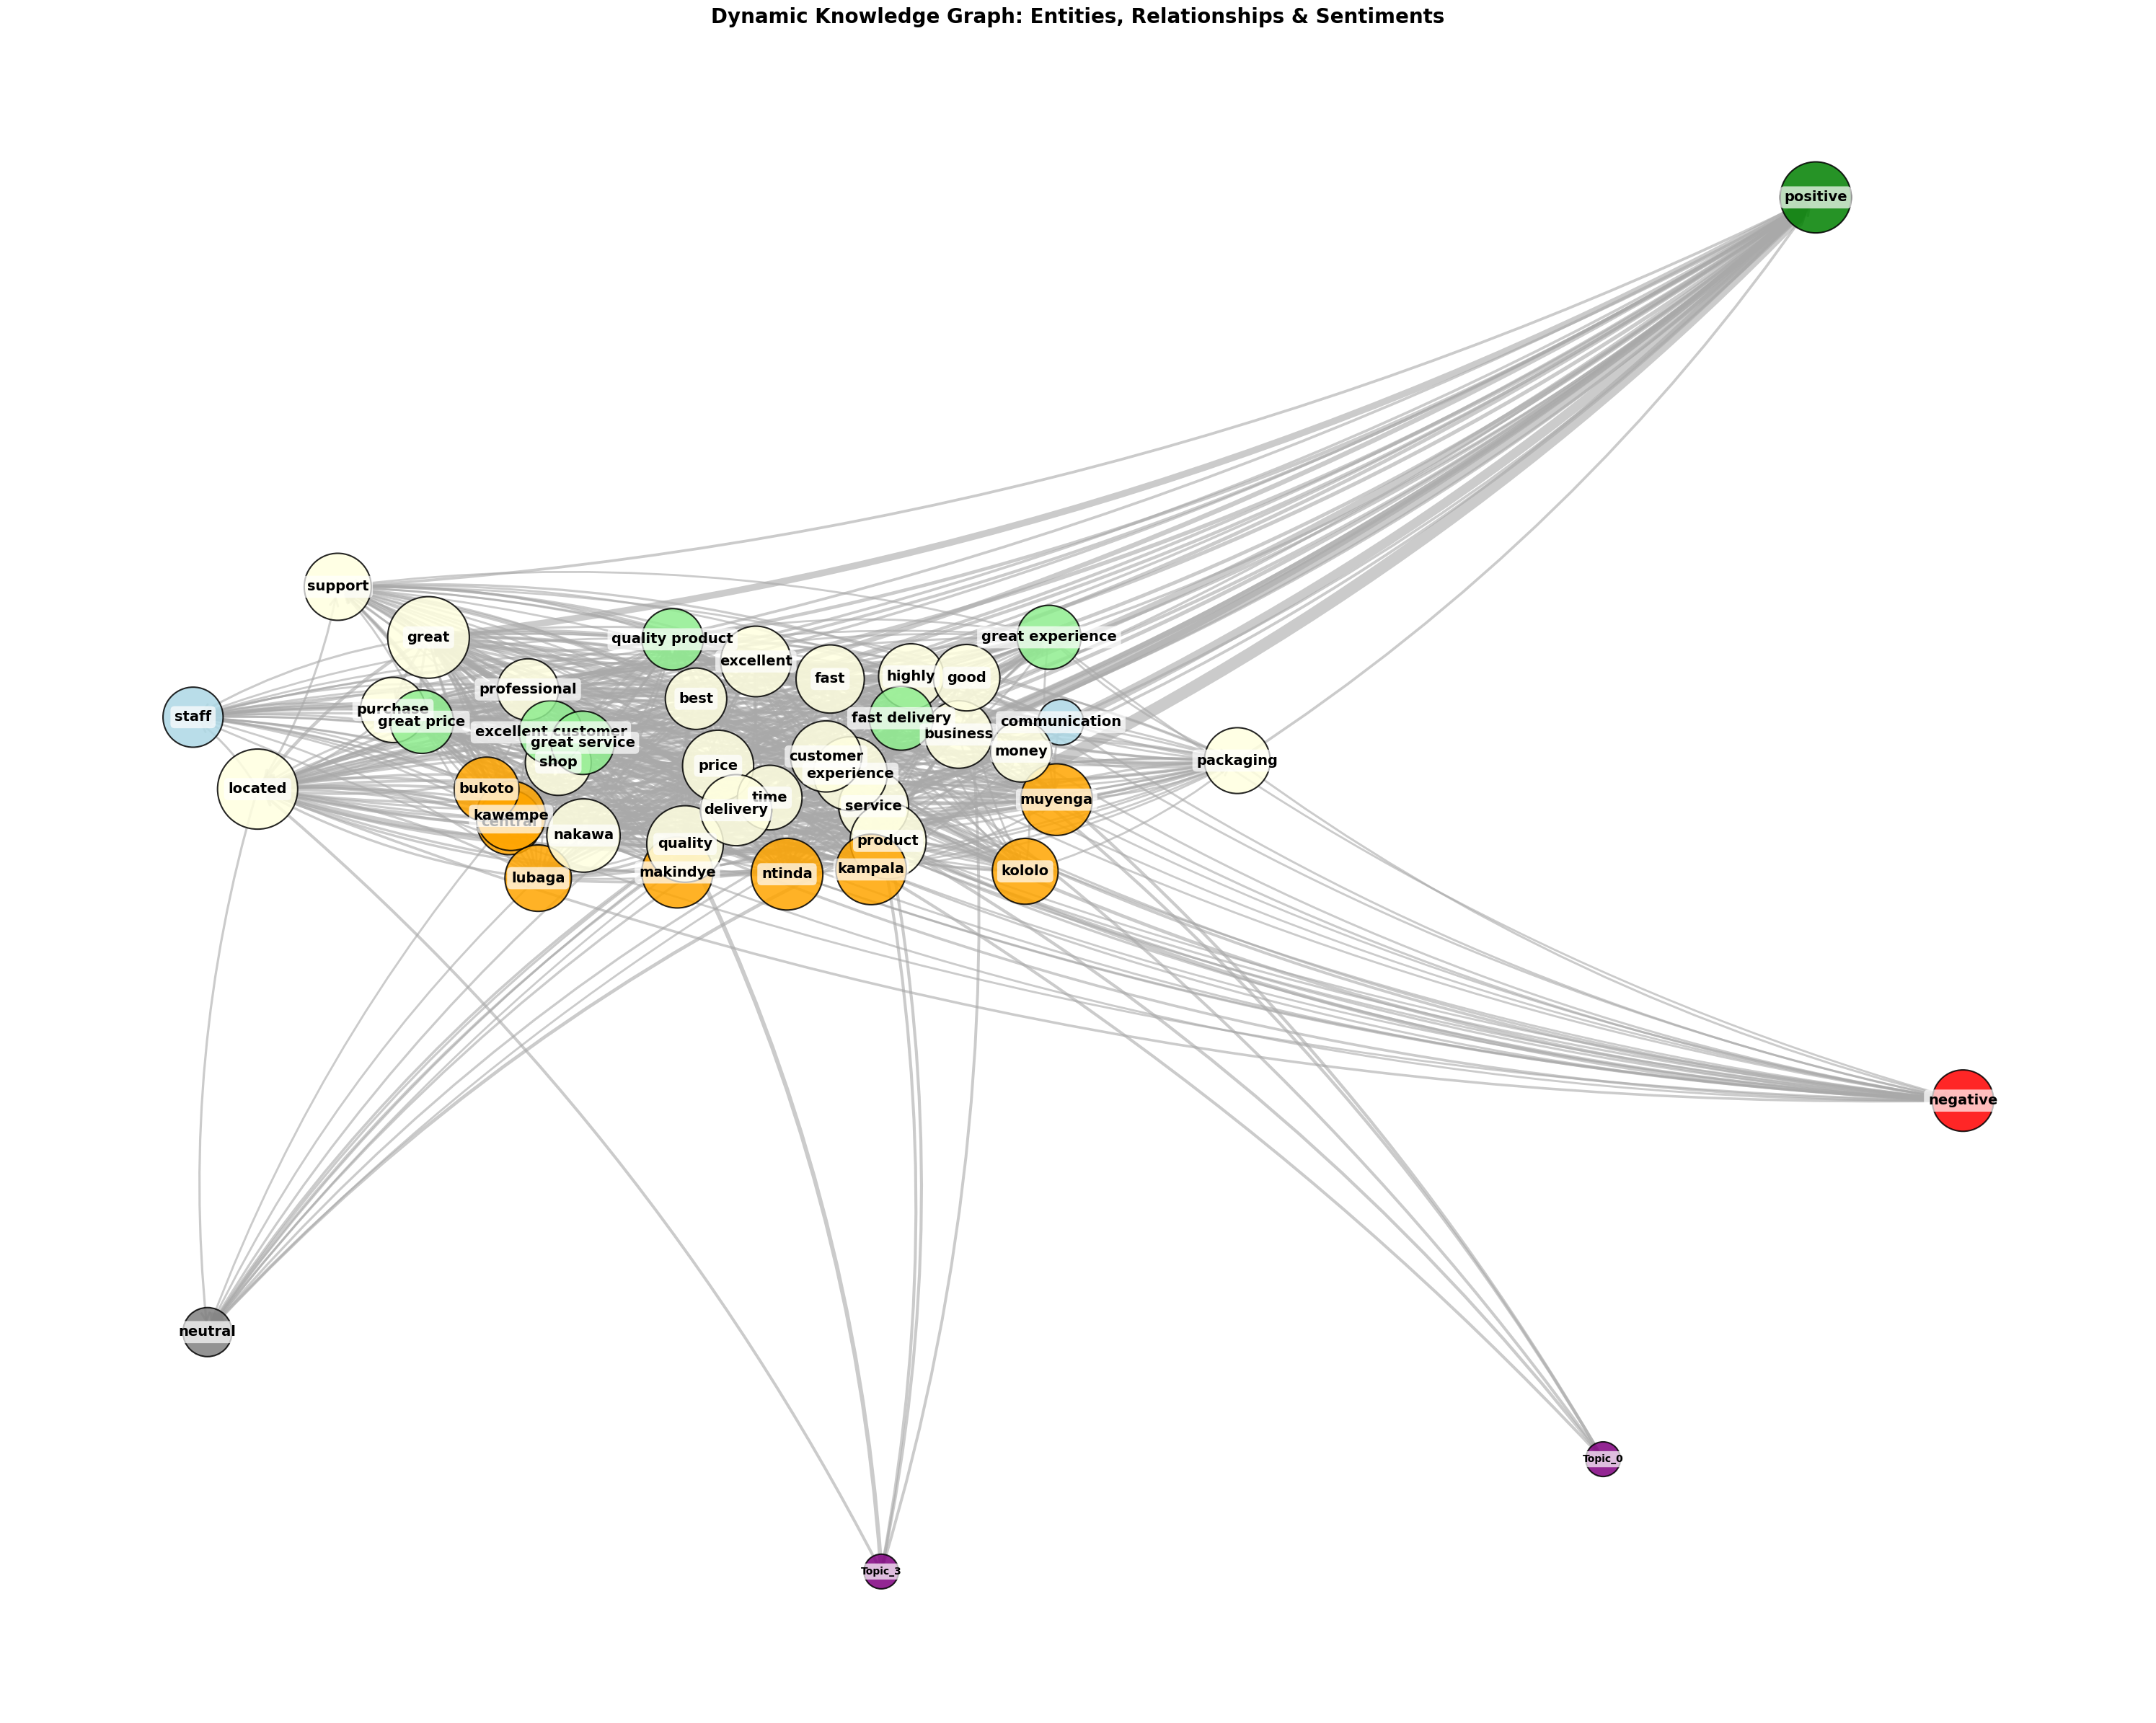

✅ Knowledge graph visualized successfully!

✅ Dynamic Knowledge Graph Construction Complete!


In [ ]:
# Enhanced Dynamic Knowledge Graph Construction
import networkx as nx
from collections import defaultdict, Counter
from sklearn.feature_extraction.text import TfidfVectorizer
import re

print("=" * 70)
print("DYNAMIC KNOWLEDGE GRAPH CONSTRUCTION")
print("=" * 70)
print("Building a comprehensive knowledge graph with dynamic entity extraction...")

try:
    # Build knowledge graph (using DiGraph for directed relationships)
    G = nx.DiGraph()
    
    # ========================================================================
    # PART 1: DYNAMIC ENTITY EXTRACTION FROM ACTUAL DATA
    # ========================================================================
    print("\n" + "=" * 70)
    print("STEP 1: Dynamic Entity Extraction")
    print("=" * 70)
    
    # Extract all words from reviews for dynamic entity discovery
    all_words = []
    all_bigrams = []
    
    for text in df_reviews_with_sentiment['cleaned_text'].dropna():
        words = str(text).lower().split()
        all_words.extend(words)
        # Create bigrams (two-word phrases)
        for i in range(len(words) - 1):
            all_bigrams.append(f"{words[i]} {words[i+1]}")
    
    # Count word frequencies
    word_freq = Counter(all_words)
    bigram_freq = Counter(all_bigrams)
    
    # Dynamic extraction of important entities based on frequency and business relevance
    print("Extracting entities from review data...")
    
    # 1. Extract top keywords (entities) dynamically
    top_keywords = [word for word, freq in word_freq.most_common(100) 
                    if len(word) > 3 and freq > 10]  # Minimum length and frequency
    
    # 2. Extract important bigrams (phrases)
    top_bigrams = [bigram for bigram, freq in bigram_freq.most_common(50) 
                   if freq > 5]
    
    # 3. Predefined entity categories (expanded)
    entity_categories = {
        'service': ['service', 'delivery', 'support', 'customer service', 'help', 'assistance'],
        'product': ['product', 'quality', 'item', 'goods', 'merchandise', 'purchase'],
        'price': ['price', 'cost', 'expensive', 'cheap', 'affordable', 'value', 'money', 'payment'],
        'location': ['kampala', 'nakawa', 'kawempe', 'makindye', 'lubaga', 'kololo', 
                    'ntinda', 'bukoto', 'muyenga', 'shop', 'store', 'located'],
        'time': ['late', 'fast', 'quick', 'delay', 'time', 'early', 'prompt', 'slow'],
        'experience': ['experience', 'great', 'excellent', 'amazing', 'wonderful', 'fantastic'],
        'staff': ['staff', 'employee', 'worker', 'personnel', 'team', 'manager'],
        'communication': ['communication', 'response', 'contact', 'message', 'reply']
    }
    
    # 4. Extract additional entities from topics (if LDA model exists)
    topic_entities = []
    if 'lda_model' in locals() and lda_model is not None and 'dictionary' in locals():
        try:
            for topic_id in range(5):  # Assuming 5 topics
                topic_words = [word for word, _ in lda_model.show_topic(topic_id, topn=10)]
                topic_entities.extend(topic_words)
            topic_entities = list(set(topic_entities))  # Remove duplicates
            print(f"  Extracted {len(topic_entities)} entities from topics")
        except:
            pass
    
    # 5. Extract location entities from data
    location_entities = []
    if 'location' in df_reviews_with_sentiment.columns:
        location_entities = df_reviews_with_sentiment['location'].dropna().unique().tolist()
        location_entities = [str(loc).lower() for loc in location_entities]
    
    # Combine all entities
    all_entities = set()
    
    # Add category entities
    for category, keywords in entity_categories.items():
        all_entities.add(category)
        all_entities.update(keywords)
    
    # Add top keywords as entities
    all_entities.update(top_keywords[:30])  # Top 30 keywords
    
    # Add important bigrams as entities
    all_entities.update(top_bigrams[:20])  # Top 20 bigrams
    
    # Add topic entities
    all_entities.update(topic_entities)
    
    # Add locations
    all_entities.update(location_entities)
    
    print(f"  Total unique entities extracted: {len(all_entities)}")
    print(f"  - Category entities: {len(entity_categories)}")
    print(f"  - Top keywords: {len(top_keywords[:30])}")
    print(f"  - Important phrases: {len(top_bigrams[:20])}")
    print(f"  - Locations: {len(location_entities)}")
    
    # ========================================================================
    # PART 2: ADD NODES TO GRAPH
    # ========================================================================
    print("\n" + "=" * 70)
    print("STEP 2: Building Graph Nodes")
    print("=" * 70)
    
    # Add sentiment nodes
    G.add_node('positive', type='sentiment', color='green')
    G.add_node('negative', type='sentiment', color='red')
    G.add_node('neutral', type='sentiment', color='gray')
    
    # Add entity category nodes
    for category in entity_categories.keys():
        G.add_node(category, type='entity_category', color='lightblue')
    
    # Add location nodes
    for loc in location_entities:
        if loc and len(str(loc)) > 0:
            G.add_node(loc, type='location', color='orange')
    
    # Add keyword entity nodes
    for keyword in top_keywords[:30]:
        G.add_node(keyword, type='keyword', color='lightyellow', frequency=word_freq[keyword])
    
    # Add bigram nodes (phrases)
    for bigram in top_bigrams[:20]:
        G.add_node(bigram, type='phrase', color='lightgreen', frequency=bigram_freq[bigram])
    
    # Add topic nodes (if available)
    if 'lda_model' in locals() and lda_model is not None:
        try:
            for topic_id in range(5):
                topic_name = f"Topic_{topic_id}"
                G.add_node(topic_name, type='topic', color='purple')
        except:
            pass
    
    print(f"✅ Added {G.number_of_nodes()} nodes to the graph")
    
    # ========================================================================
    # PART 3: EXTRACT RELATIONSHIPS
    # ========================================================================
    print("\n" + "=" * 70)
    print("STEP 3: Extracting Relationships")
    print("=" * 70)
    
    relationships_count = 0
    
    # Relationship Type 1: Entity -> Sentiment
    print("  Extracting entity-sentiment relationships...")
    for idx, row in df_reviews_with_sentiment.iterrows():
        try:
            text = str(row.get('cleaned_text', '')).lower()
            sentiment = str(row.get('sentiment', 'neutral')).lower()
            
            # Find entities mentioned in text
            mentioned_entities = []
            
            # Check category keywords
            for category, keywords in entity_categories.items():
                if any(keyword in text for keyword in keywords):
                    mentioned_entities.append(category)
            
            # Check top keywords
            for keyword in top_keywords[:30]:
                if keyword in text:
                    mentioned_entities.append(keyword)
            
            # Check bigrams
            for bigram in top_bigrams[:20]:
                if bigram in text:
                    mentioned_entities.append(bigram)
            
            # Create entity -> sentiment relationships
            for entity in mentioned_entities:
                if entity in G.nodes():
                    if not G.has_edge(entity, sentiment):
                        G.add_edge(entity, sentiment, type='has_sentiment', weight=1)
                    else:
                        G[entity][sentiment]['weight'] += 1
                    relationships_count += 1
        except Exception as e:
            continue
    
    print(f"  ✓ Entity-Sentiment relationships: {relationships_count}")
    
    # Relationship Type 2: Entity -> Entity (co-occurrence)
    print("  Extracting entity co-occurrence relationships...")
    entity_cooccurrence = defaultdict(int)
    
    for text in df_reviews_with_sentiment['cleaned_text'].dropna():
        text_lower = str(text).lower()
        mentioned = []
        
        # Find all entities in this text
        for node in G.nodes():
            if G.nodes[node].get('type') in ['entity_category', 'keyword', 'phrase', 'location']:
                if node in text_lower:
                    mentioned.append(node)
        
        # Create co-occurrence pairs
        for i, ent1 in enumerate(mentioned):
            for ent2 in mentioned[i+1:]:
                if ent1 != ent2:
                    pair = tuple(sorted([ent1, ent2]))
                    entity_cooccurrence[pair] += 1
    
    # Add co-occurrence edges (only if they co-occur frequently)
    cooccur_count = 0
    for (ent1, ent2), count in entity_cooccurrence.items():
        if count >= 5 and ent1 in G.nodes() and ent2 in G.nodes():  # Minimum co-occurrence threshold
            if not G.has_edge(ent1, ent2):
                G.add_edge(ent1, ent2, type='co_occurs_with', weight=count)
            else:
                G[ent1][ent2]['weight'] += count
            cooccur_count += 1
    
    print(f"  ✓ Entity co-occurrence relationships: {cooccur_count}")
    relationships_count += cooccur_count
    
    # Relationship Type 3: Location -> Entity
    print("  Extracting location-entity relationships...")
    if 'location' in df_reviews_with_sentiment.columns:
        loc_entity_count = 0
        for location in location_entities:
            if location and location in G.nodes():
                # Find reviews from this location
                loc_reviews = df_reviews_with_sentiment[
                    df_reviews_with_sentiment['location'].str.lower().str.contains(location, na=False)
                ]
                
                # Find entities in these reviews
                entity_counts = Counter()
                for text in loc_reviews['cleaned_text'].dropna():
                    text_lower = str(text).lower()
                    for node in G.nodes():
                        if G.nodes[node].get('type') in ['entity_category', 'keyword']:
                            if node in text_lower:
                                entity_counts[node] += 1
                
                # Add edges for top entities in this location
                for entity, count in entity_counts.most_common(5):
                    if entity in G.nodes() and count >= 3:
                        if not G.has_edge(location, entity):
                            G.add_edge(location, entity, type='has_entity', weight=count)
                        else:
                            G[location][entity]['weight'] += count
                        loc_entity_count += 1
        
        print(f"  ✓ Location-Entity relationships: {loc_entity_count}")
        relationships_count += loc_entity_count
    
    # Relationship Type 4: Topic -> Entity (if topics available)
    if 'lda_model' in locals() and lda_model is not None and 'df_reviews_with_sentiment' in locals():
        print("  Extracting topic-entity relationships...")
        try:
            if 'topic' in df_reviews_with_sentiment.columns:
                topic_entity_count = 0
                for topic_id in range(5):
                    topic_name = f"Topic_{topic_id}"
                    if topic_name in G.nodes():
                        # Find reviews in this topic
                        topic_reviews = df_reviews_with_sentiment[
                            df_reviews_with_sentiment['topic'] == topic_id
                        ]
                        
                        # Find entities in these reviews
                        entity_counts = Counter()
                        for text in topic_reviews['cleaned_text'].dropna():
                            text_lower = str(text).lower()
                            for node in G.nodes():
                                if G.nodes[node].get('type') in ['entity_category', 'keyword']:
                                    if node in text_lower:
                                        entity_counts[node] += 1
                        
                        # Add edges for top entities in this topic
                        for entity, count in entity_counts.most_common(5):
                            if entity in G.nodes() and count >= 3:
                                if not G.has_edge(topic_name, entity):
                                    G.add_edge(topic_name, entity, type='has_entity', weight=count)
                                else:
                                    G[topic_name][entity]['weight'] += count
                                topic_entity_count += 1
                
                print(f"  ✓ Topic-Entity relationships: {topic_entity_count}")
                relationships_count += topic_entity_count
        except Exception as e:
            print(f"  ⚠️ Could not extract topic-entity relationships: {e}")
    
    # ========================================================================
    # PART 4: GRAPH STATISTICS AND VISUALIZATION
    # ========================================================================
    print("\n" + "=" * 70)
    print("STEP 4: Graph Statistics")
    print("=" * 70)
    
    print(f"✅ Dynamic Knowledge Graph Created!")
    print(f"  Total Nodes: {G.number_of_nodes()}")
    print(f"  Total Edges: {G.number_of_edges()}")
    print(f"  Total Relationships: {relationships_count}")
    
    # Detailed statistics
    node_types = defaultdict(int)
    for node in G.nodes(data=True):
        node_type = node[1].get('type', 'unknown')
        node_types[node_type] += 1
    
    print(f"\n  Node Types:")
    for node_type, count in sorted(node_types.items()):
        print(f"    - {node_type}: {count}")
    
    edge_types = defaultdict(int)
    for edge in G.edges(data=True):
        edge_type = edge[2].get('type', 'unknown')
        edge_types[edge_type] += 1
    
    print(f"\n  Relationship Types:")
    for edge_type, count in sorted(edge_types.items()):
        print(f"    - {edge_type}: {count}")
    
    # Visualize knowledge graph
    print("\n" + "=" * 70)
    print("STEP 5: Visualizing Knowledge Graph")
    print("=" * 70)
    
    try:
        # Create a filtered view for visualization - prioritize diversity and importance
        # Show most important nodes AND ensure we include different node types for better visualization
        node_degrees = dict(G.degree())
        
        # Get top nodes by importance (degree)
        top_by_degree = sorted(node_degrees.items(), key=lambda x: x[1], reverse=True)[:40]
        
        # Also include all sentiment nodes (critical for visualization)
        sentiment_nodes = [n for n, d in G.nodes(data=True) if d.get('type') == 'sentiment']
        
        # Include some nodes from each type for diversity
        node_types_included = {}
        for node, data in G.nodes(data=True):
            node_type = data.get('type', 'unknown')
            if node_type not in node_types_included:
                node_types_included[node_type] = []
            node_types_included[node_type].append(node)
        
        # Select diverse set: top nodes + sentiments + representatives from each type
        top_node_names = set([node for node, _ in top_by_degree])
        top_node_names.update(sentiment_nodes)  # Always include all sentiments
        
        # Add a few representatives from each node type
        for node_type, nodes in node_types_included.items():
            if node_type != 'sentiment':  # Already included
                # Sort by degree and take top 3-5 of each type
                type_nodes_sorted = sorted(nodes, key=lambda n: node_degrees.get(n, 0), reverse=True)
                top_node_names.update(type_nodes_sorted[:5])
        
        # Limit to max 45 nodes for better spacing (reduce if too many)
        if len(top_node_names) > 45:
            # Keep all sentiments and top by degree
            final_nodes = set(sentiment_nodes)
            remaining = sorted([n for n in top_node_names if n not in final_nodes], 
                             key=lambda n: node_degrees.get(n, 0), reverse=True)
            final_nodes.update(remaining[:45 - len(final_nodes)])
            top_node_names = final_nodes
        
        top_node_names = list(top_node_names)
        print(f"  Selected {len(top_node_names)} nodes for visualization")
        
        # Create subgraph with selected nodes
        G_viz = G.subgraph(top_node_names).copy()
        
        # Increase figure size for better readability
        plt.figure(figsize=(30, 24))
        
        # Use multiple layout strategies for better node distribution
        print("  Computing optimal node positions for better visualization...")
        
        # Strategy 1: Try force-directed layout with larger k (optimal distance)
        # Calculate optimal k based on number of nodes - more aggressive spacing
        num_nodes = len(G_viz.nodes())
        optimal_k = max(5.0, num_nodes ** 0.7)  # Scale k more aggressively for better spacing
        
        # First try: Spring layout with larger k and more iterations
        try:
            pos = nx.spring_layout(G_viz, k=optimal_k, iterations=300, seed=42, 
                                  repulsive_factor=0.8, scale=2.0)
            print(f"  Using spring layout with k={optimal_k:.2f}")
        except:
            # Fallback: Standard spring layout with increased k
            pos = nx.spring_layout(G_viz, k=optimal_k, iterations=300, seed=42)
        
        # Strategy 2: Apply additional spreading using kamada_kawai if possible
        # This creates more uniform distribution
        try:
            print("  Applying Kamada-Kawai layout for better spacing...")
            pos_kk = nx.kamada_kawai_layout(G_viz, scale=2.0)
            # Blend the two layouts for better distribution
            for node in pos:
                pos[node] = (pos[node][0] * 0.6 + pos_kk[node][0] * 0.4,
                            pos[node][1] * 0.6 + pos_kk[node][1] * 0.4)
        except:
            print("  Using spring layout only")
        
        # Strategy 3: Normalize and scale positions to use full canvas
        # Extract x and y coordinates
        x_vals = [pos[node][0] for node in G_viz.nodes()]
        y_vals = [pos[node][1] for node in G_viz.nodes()]
        
        # Normalize to [-1, 1] range
        if max(x_vals) > min(x_vals):
            x_range = max(x_vals) - min(x_vals)
            x_center = (max(x_vals) + min(x_vals)) / 2
            x_scale = 2.0 / x_range if x_range > 0 else 1.0
        else:
            x_center = x_vals[0] if x_vals else 0
            x_scale = 1.0
        
        if max(y_vals) > min(y_vals):
            y_range = max(y_vals) - min(y_vals)
            y_center = (max(y_vals) + min(y_vals)) / 2
            y_scale = 2.0 / y_range if y_range > 0 else 1.0
        else:
            y_center = y_vals[0] if y_vals else 0
            y_scale = 1.0
        
        # Scale and center all positions to use full canvas area
        for node in pos:
            x_new = (pos[node][0] - x_center) * x_scale * 0.9  # 0.9 to add margins
            y_new = (pos[node][1] - y_center) * y_scale * 0.9
            pos[node] = (x_new, y_new)
        
        print(f"  ✅ Node positions optimized for {num_nodes} nodes")
        
        # Color nodes by type
        node_colors_map = {
            'sentiment': {'positive': 'green', 'negative': 'red', 'neutral': 'gray'},
            'entity_category': 'lightblue',
            'location': 'orange',
            'keyword': 'lightyellow',
            'phrase': 'lightgreen',
            'topic': 'purple'
        }
        
        node_colors = []
        node_sizes = []
        
        for node in G_viz.nodes():
            node_type = G_viz.nodes[node].get('type', 'unknown')
            if node_type == 'sentiment':
                node_colors.append(node_colors_map['sentiment'].get(node, 'gray'))
            else:
                node_colors.append(node_colors_map.get(node_type, 'lightgray'))
            
            # Size based on degree (importance) - increased sizes
            degree = node_degrees.get(node, 1)
            node_sizes.append(800 + degree * 80)  # Larger nodes
        
        # Draw nodes first (so edges appear on top)
        nx.draw_networkx_nodes(G_viz, pos, node_color=node_colors, 
                              node_size=node_sizes, alpha=0.85, edgecolors='black', linewidths=1.5)
        
        # Draw edges with weights - MUCH THICKER EDGES
        edges = G_viz.edges()
        weights = [G_viz[u][v].get('weight', 1) for u, v in edges]
        # Scale edge widths: minimum 2, maximum 12, based on weight
        min_weight = min(weights) if weights else 1
        max_weight = max(weights) if weights else 1
        edge_widths = []
        for w in weights:
            if max_weight > min_weight:
                # Normalize and scale between 2 and 12
                normalized = (w - min_weight) / (max_weight - min_weight)
                edge_widths.append(2 + normalized * 10)
            else:
                edge_widths.append(3)  # Default width
        
        nx.draw_networkx_edges(G_viz, pos, alpha=0.6, width=edge_widths,
                              edge_color='darkgray', arrows=True, arrowsize=20, 
                              arrowstyle='->', connectionstyle='arc3,rad=0.1')
        
        # Draw labels for ALL nodes - bigger font
        labels = {node: node for node in G_viz.nodes()}
        
        # Use different font sizes based on node importance
        label_font_sizes = {}
        for node in G_viz.nodes():
            degree = node_degrees.get(node, 1)
            node_type = G_viz.nodes[node].get('type', 'unknown')
            # Sentiment nodes and high-degree nodes get bigger font
            if node_type == 'sentiment' or degree > 10:
                label_font_sizes[node] = 14
            elif degree > 5:
                label_font_sizes[node] = 12
            else:
                label_font_sizes[node] = 10
        
        # Draw labels with individual font sizes
        for node, label in labels.items():
            x, y = pos[node]
            plt.text(x, y, label, fontsize=label_font_sizes.get(node, 10), 
                    fontweight='bold', ha='center', va='center',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', 
                             edgecolor='none', alpha=0.7))
        
        plt.title("Dynamic Knowledge Graph: Entities, Relationships & Sentiments", 
                 fontsize=20, fontweight='bold', pad=30)
        plt.axis('off')
        plt.tight_layout()
        plt.show()
        
        print("✅ Knowledge graph visualized successfully!")
        
    except Exception as e:
        print(f"⚠️ Error visualizing graph: {e}")
        print("   Graph structure is still saved")
        import traceback
        traceback.print_exc()
    
    print("\n" + "=" * 70)
    print("✅ Dynamic Knowledge Graph Construction Complete!")
    print("=" * 70)
    
except Exception as e:
    print(f"❌ Error building knowledge graph: {e}")
    print("⚠️ Creating empty graph as fallback...")
    import traceback
    traceback.print_exc()
    G = nx.DiGraph()


## Part 5: Save Models and Results

Save all trained models and analysis results for use in the interaction layer.


In [ ]:
# Save models and results
import pickle
import os

os.makedirs('../../backend/data/models', exist_ok=True)
os.makedirs('../../backend/data/processed', exist_ok=True)

# Save sentiment analyzer
with open('../../backend/data/models/sentiment_analyzer.pkl', 'wb') as f:
    pickle.dump(analyzer, f)
print("✅ Sentiment analyzer saved")

# Save LDA model
lda_model.save('../../backend/data/models/lda_model')
print("✅ LDA topic model saved")

# Save knowledge graph
with open('../../backend/data/models/knowledge_graph.pkl', 'wb') as f:
    pickle.dump(G, f)
print("✅ Knowledge graph saved")

# Save results with sentiment
df_reviews_with_sentiment.to_csv('../../backend/data/processed/reviews_with_sentiment.csv', index=False)
print("✅ Results saved")

print("\n=== Milestone 2 Summary ===")
print(f"✅ Sentiment analysis completed on {len(df_reviews_with_sentiment)} reviews")
print(f"✅ Topic modeling: {num_topics} topics identified")
print(f"✅ Knowledge graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")


✅ Sentiment analyzer saved
✅ LDA topic model saved
✅ Knowledge graph saved
✅ Results saved

=== Milestone 2 Summary ===
✅ Sentiment analysis completed on 5100 reviews
✅ Topic modeling: 5 topics identified
✅ Knowledge graph: 71 nodes, 1285 edges


## Summary

This notebook has implemented the Understanding & Reasoning Engine:

1. ✅ **Understanding (NLP)**: Sentiment analysis to understand customer opinions
2. ✅ **Reasoning (Knowledge Graph)**: Entity-sentiment relationships
3. ✅ **Reasoning (Topic Modeling)**: Identified key topics in feedback
4. ✅ **Model Persistence**: Saved all models for use in interaction layer

### Cognitive Pillars Demonstrated:
- **Understand**: Sentiment analysis extracts meaning from unstructured text
- **Reason**: Knowledge graphs and topic models enable reasoning about customer feedback


